# <u>Naive Bayes (NB)</u>

## Topics

* [1. Core Idea](#idea)
* [2. Key assumption (the "naive" part)](#naive)
* [3. How it models features](#models)
    * [3.1 Numerical Features](#numerical)
    * [3.2 Categorical Features](#categorical)
* [4. Laplace smoothing](#smoothing)
* [5. Properties & intuition](#properties)
* [6. Typical application](#apply)
* [7. Classification rule](#rule)
* [8. Naive Bayes implementation (Spam mails)](#implement)
* [9. Naive Bayes library](#library)


In [2]:
import numpy as np # for rnadom number, linear algebra and general mathematic operations
from matplotlib import pyplot as plt # for plotting in 2d
import plotly.express as px # for plotting in 3d
import plotly.graph_objects as go # for plotting in 3d
from scipy.stats import norm # for normal pdf
from sklearn.naive_bayes import GaussianNB # for Naive Bayes
print("Setup complete")

Setup complete


<a class="anchor" id="idea"></a>
# 1. Core idea

Naive Bayes is a generative, probabilistic classifier that computes the probability of each class using Bayes theorem:
$$
p(y=k \mid x)=\frac{p(x \mid y=k)p(y=k)}{p(x)}=\frac{p(x \mid y=k)\pi_k}{\sum_{j=1}^g p(x \mid y=j)p(y=j)}
$$

- $p(y=k)$: prior (class frequency)
- $p(x \mid y=k)$: likelihood
- Predict class with highest posterior probability

<a class="anchor" id="naive"></a>
# 2. Key assumption (the "naive" part)

NB assumes conditional independence of features given the class:

$$
\begin{align*}
p(x \mid y=k)&=p((x_1,\ldots,x_p) \mid y=k)\\
&=\prod_{j=1}^p p(x_j \mid y=k) \\
&= \prod_{j=1}^p \frac{1}{\sqrt{2\pi\sigma_{kj}^2}}\exp\left(-\frac{1}{2\sigma_{kj}^2}(x_j - \mu_{kj})^2\right)\\
&= \prod_{j=1}^p (2\pi\sigma_{kj}^2)^{-1/2}\exp\left(-\frac{1}{2\sigma_{kj}^2}(x_j - \mu_{kj})^2\right)
\end{align*}
$$

&#128073; This simplifies modeling a lot:
- Instead of one complex joint distribution
- Only estimate univariate distributions $p(x_j \mid y=k)$ per feature are needed

<a class="anchor" id="models"></a>
# 3. How it models features

<a class="anchor" id="numerical"></a>
## 3.1 Numerical Features



- Modeled with Gaussian distributions

$$
\begin{align*}
p(y=k \mid x)&=\frac{p(x \mid y=k)\pi_k}{p(x)} \\
&\propto p(x \mid y=k)\pi_k \\
&\overset{\text{independent}}{=} \prod_{i=1}^p p(x_j \mid y=k)\pi_k \hspace{1 mm} \mid \hspace{1 mm} \text{ difference between QDA and BA is conditional independence assumption} \\
&= \pi_k \prod_{i=1}^p p(x_j \mid y=k) \\
&= \pi_k \prod_{j=1}^p (2\pi\sigma_{kj}^2)^{-1/2}\exp\left(-\frac{1}{2\sigma_{kj}^2}(x_j - \mu_{kj})^2\right) \\
&= \log \left(\pi_k \prod_{j=1}^p (2\pi\sigma_{kj}^2)^{-1/2}\exp\left(-\frac{1}{2\sigma_{kj}^2}(x_j - \mu_{kj})^2\right)\right) \\

&= \log(\pi_k) + \log\left(\prod_{j=1}^p (2\pi\sigma_{kj}^2)^{-1/2}\exp\left(-\frac{1}{2\sigma_{kj}^2}(x_j - \mu_{kj})^2\right)\right) \\

&= \log(\pi_k) + \sum_{j=1}^p \log\left( (2\pi\sigma_{kj}^2)^{-1/2}\exp\left(-\frac{1}{2\sigma_{kj}^2}(x_j - \mu_{kj})^2\right)\right) \hspace{1 mm} \mid \hspace{1 mm} = \log(\pi_k) + \sum_{j=1}^p \log(p(x_j \mid y=k))\\

&= \log(\pi_k) + \sum_{j=1}^p \left( \log((2\pi\sigma_{kj}^2)^{-1/2}) + \log\left(\exp\left(-\frac{1}{2\sigma_{kj}^2}(x_j - \mu_{kj})^2\right)\right)\right) \\

&= \log(\pi_k) + \sum_{j=1}^p \left( -\frac{1}{2} \log(2\pi\sigma_{kj}^2) -\frac{1}{2\sigma_{kj}^2}(x_j - \mu_{kj})^2\right) \\

&= \log(\pi_k) + \sum_{j=1}^p \left( -\frac{1}{2} \log(2\pi\sigma_{kj}^2) -\frac{1}{2\sigma_{kj}^2}(x_j - \mu_{kj})^2\right) \\

&= \log(\pi_k) -\frac{1}{2} \sum_{j=1}^p \left(\log(2\pi\sigma_{kj}^2) -\frac{(x_j - \mu_{kj})^2}{\sigma_{kj}^2}\right) \\

&= \log(\pi_k) -\frac{1}{2} \sum_{j=1}^p \log(2\pi\sigma_{kj}^2) -\frac{1}{2} \sum_{j=1}^p \left(\frac{(x_j - \mu_{kj})^2}{\sigma_{kj}^2}\right) \\

&= \log(\pi_k) -\frac{1}{2} \sum_{j=1}^p \log(2\pi\sigma_{kj}^2) -\frac{1}{2} \sum_{j=1}^p \left(\frac{x_j^2}{\sigma_{kj}^2} - \frac{2x_j\mu_{kj}}{\sigma_{kj}^2} + \frac{\mu_{kj}^2}{\sigma_{kj}^2}\right) \\

&= \log(\pi_k) -\frac{1}{2} \sum_{j=1}^p \log(2\pi\sigma_{kj}^2)-\frac{1}{2} \sum_{j=1}^p \frac{x_j^2}{\sigma_{kj}^2} +\frac{1}{2} \sum_{j=1}^p \frac{2x_j\mu_{kj}}{\sigma_{kj}^2} -\frac{1}{2} \sum_{j=1}^p \frac{\mu_{kj}^2}{\sigma_{kj}^2} \\

&= \underbrace{\log(\pi_k) -\frac{1}{2} \sum_{j=1}^p \log(2\pi\sigma_{kj}^2) -\frac{1}{2} \sum_{j=1}^p \frac{\mu_{kj}^2}{\sigma_{kj}^2}}_{w_{0k}} + \underbrace{\sum_{j=1}^p \frac{\mu_{kj}}{\sigma_{kj}^2}x_j}_{w_k} - \underbrace{\frac{1}{2} \sum_{j=1}^p \frac{1}{\sigma_{kj}^2}x_j^2}_{W_k}=: f_k(x)   \\

\end{align*}
$$

- Group terms:
    - Quadratic in $x_j: x_j^2$
    - Linear in $x_j: x_j$
    - Constant terms


- Estimate mean and variance per feature & class

Class priors: $$\hat{\pi}_k=\frac{n_k}{n}$$

- $n$ is total number of observations
- $n_k$ number observation in class $k$

Class means for each feature $j$ and class $k$: $$\hat{\mu}_{kj}=\frac{1}{n_k} \sum_{i:y^{(i)}=k} x^{(ij)}$$


Class variance: $$\hat{\sigma}_{kj}^2=\frac{1}{n_k-1}  \sum_{i:y^{(i)}=k} (x^{(ij)}-\hat{\mu}_{kj})^2$$

- Equivalent to QDA with diagonal covariance matrix

&#128073; These define: $p(x_j \mid y=k)=\mathcal{N}(\mu_{kj},\sigma_{kj}^2)$

### Decision boundary

**For two classes $k$ and $l$ the boundary is where:**

$$
f_k(x) = f_l(x)
$$

**So set to zero and solve for an axis to get quadratic descision boundary:**

$$
f_k(x) - f_l(x)=0
$$

<a class="anchor" id="categorical"></a>
## 3.2 Categorical Features

- Modeled with categorical (frequency-based) distributions for $p(x_j \mid y=k)$
- Estimate probabilities $p_{kjm}$ by counting occurrences

$$
p(x_j \mid y=k) = \prod_m p_{kjm}^{[x_j=m]} \overset{\text{independence}}\Longrightarrow p(x \mid y=k) = \prod_{j=1}^p \underbrace{\prod_m p_{kjm}^{[x_j=m]}}_{p(x_j \mid y=k)}
$$

- $p_{kjm}=p(x_j=m \mid y=k)$ = Probability that in class $k$ the $j$-th feature $x_j$ has value $x_j=m$ 

- More precisely $p_{kjm}=\frac{n_{kjm}}{n_k} \Rightarrow p_{kjm}^{[x_j=m]}=(\frac{n_{kjm}}{n_k})^{[x_j=m]}$ with $n_{kjm}$ being the number of observation in class $k$ where the $j$-th feature $x_j$ has value $x_j=m$ and $n_k$ the total counts in class $k$

- $[x_j = m]=\begin{cases} 1 &\text{if }x_j = m \\ 0 &\text{otherwise}   \end{cases} \hspace{1 mm}$ keeps only the probability for the actual value

**Example**

$$
\begin{array}{}
\hline
\text{Level} & \text{Gender} & \text{Survived} \\
\hline
2nd & \text{male} & \text{no} \\
1st & \text{male}  & \text{yes}  \\
3rd & \text{female}  & \text{yes} \\
1st & \text{female}  & \text{yes}  \\
2nd & \text{female}  & \text{yes} \\
3rd & \text{female}  & \text{no} \\
\end{array}
$$

$$
\begin{align*}
p(x_{\text{gender}} \mid y = \text{yes})&=\prod_{m \in \text{male,female}} p_{\text{yes},\text{sex},m}^{[x_\text{gender}=m]} \\
&=p_{\text{yes},\text{sex},\text{male}}^{[x_\text{gender}=\text{male}]} \cdot p_{\text{yes},\text{sex},\text{female}}^{[x_\text{gender}=\text{female}]}  \\

&=\frac{1}{4}^{[x_\text{gender}=\text{male}]} \cdot \frac{3}{4}^{[x_\text{gender}=\text{female}]} = \begin{cases} \frac{1}{4} &\text{if }x_\text{gender} = \text{male} \\  \frac{3}{4} &\text{if }x_\text{gender} = \text{female}  \end{cases}
\end{align*}
$$

For a full observation (e.g., Level + Gender):

$$
\begin{align*}
p((x_\text{Level},x_\text{Gender}) \mid y=\text{yes}) &\overset{\text{independence}}{=} p(x_\text{Level} \mid y=\text{yes}) \cdot p(x_\text{Gender} \mid y=\text{yes}) \\
&=  \prod_m p_{\text{yes},\text{Level},m}^{[x_\text{Level}=m]} \cdot \prod_m p_{\text{yes},\text{Gender},m}^{[x_\text{Gender}=m]} \\
\end{align*}
$$



<a class="anchor" id="smoothing"></a>
# 4. Laplace smoothing

## &#10071; Problem:

- If a feature value never appears in a class $\rightarrow$ probability = 0
- This makes the whole product = 0

Example: 

$$
\begin{array}{}
\hline
\text{Level} & \text{Gender} & \text{Survived} \\
\hline
2nd & \text{male} & \text{no} \\
1st & \text{male}  & \text{yes}  \\
3rd & \text{female}  & \text{yes} \\
1st & \text{female}  & \text{yes}  \\
2nd & \text{female}  & \text{yes} \\
3rd & \text{female}  & \text{no} \\
\end{array}
$$

We want the posterior $p(y=\text{no} \mid (x_\text{Level}=1st,x_\text{Gender}=\text{male}))$ so the probability of not surviving as a male in the first level.

$$
\begin{align*}
p(y=\text{no} \mid (x_\text{Level}=1st,x_\text{Gender}=\text{male}))&=\frac{p((x_\text{Level}=1st,x_\text{Gender}=\text{male}) \mid y=\text{no}) \cdot p(y=\text{no})}{p(x_\text{Level}=1st,x_\text{Gender}=\text{male})} \\

&=\frac{p((x_\text{Level}=1st,x_\text{Gender}=\text{male}) \mid y=\text{no}) \cdot p(y=\text{no})}{\sum_{j \in \{\text{yes},\text{no}\}}p((x_\text{Level}=1st,x_\text{Gender}=\text{male})\mid y=j) \cdot p(y=j)} \\

&\overset{\text{independence}}{=}\frac{p(x_\text{Level}=1st\mid y=\text{no}) \cdot p(x_\text{Gender}=\text{male}\mid y=\text{no}) \cdot p(y=\text{no})}{\sum_{j \in \{\text{yes},\text{no}\}}p(x_\text{Level}=1st\mid y=j) \cdot p(x_\text{Gender}=\text{male}\mid y=j) \cdot p(y=j)} \\

&\text{Problem: Value 1st of feature Level never appears in class no} \\

&=\frac{0 \cdot p(x_\text{Gender}=\text{male}\mid y=\text{no}) \cdot p(y=\text{no})}{\sum_{j \in \{\text{yes},\text{no}\}}p(x_\text{Level}=1st\mid y=j) \cdot p(x_\text{Gender}=\text{male}\mid y=j) \cdot p(y=j)}=0 \\


\end{align*}
$$


## &#129504; Solution:

- Add a small constant $\alpha > 0$ (usually $\alpha=1$):


$$
p(x_j=m \mid y=k)=\frac{n_{kjm} + \alpha}{n_k + \alpha M_j} \\

p(x_j \mid y=k)=\prod_m (\frac{n_{kjm} + \alpha}{n_k + \alpha M_j})^{[x_j=m]}



$$

- $M_j$ is number of possible values of $x_j$

## &#128202; Final score 
$$
p(x_j=m \mid y=k)=\frac{n_{kjm} + \alpha}{n_k + \alpha M_j} \\
$$

$$
f_k(x)=\log(\pi_k) + \sum_{j=1}^p \log(p(x_j \mid y=k))
$$


<a class="anchor" id="properties"></a>
# 5. Properties & intuition

- Simple and fast
- Works well even with high-dimensional data
- Handles mixed data types (numerical + categorical)
- Despite wrong independence assumption $\rightarrow$ often performs surprisingly well

<a class="anchor" id="apply"></a>
# 6. Typical application

Classic example: spam filtering

- Features = word counts
- Assumes words occur independently (not true, but still effective)

<a class="anchor" id="rule"></a>
# 7. Classification rule

- Compute a score for each class: $$f_k(x)$$
- Predict the class with the highest score: $$h(x)=\hat{y}=\underset{k \in \{1,\ldots,g\}}{\arg\max} f_k(x)$$



<a class="anchor" id="implement"></a>
# 8. Naive Bayes implementation (Spam mails)

{'classes': array([0, 1]), 'pi': {np.int64(0): 0.5, np.int64(1): 0.5}, 'mu': {np.int64(0): array([9.87940718, 1.93466341]), np.int64(1): array([19.55551008,  6.68461391])}, 'var': {np.int64(0): array([2.51203069, 1.864295  ]), np.int64(1): array([3.14298689, 2.19694334])}}
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Naive Bayes Accuracy: 1.0


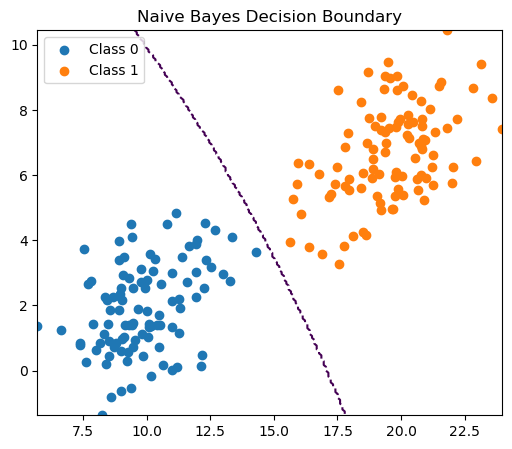

In [ ]:
# Train function
def nb_fit(X, y):
    classes = np.unique(y)
    n, p = X.shape

    pi = {}
    mu = {}
    var = {}

    for k in classes:
        Xk = X[y == k]

        pi[k] = len(Xk) / n
        mu[k] = np.mean(Xk, axis=0)
        # per-feature variance
        var[k] = np.var(Xk, axis=0, ddof=1) + 1e-9 # and ddof is Delta Degrees of Freedom (the divisor used in the calculation is N - ddof, where N represents the number of elements)

    return {
        "classes": classes,
        "pi": pi,
        "mu": mu,
        "var": var
    }


# Discriminant function
def nb_score(model, x, k):
    pi = model["pi"][k]
    mu = model["mu"][k]
    var = model["var"][k]

    # log Gaussian NB
    return (
        np.log(pi)
        - 0.5 * np.sum(np.log(2 * np.pi * var))
        - 0.5 * np.sum((x - mu) ** 2 / var)
    )


# Prediction
def nb_predict(model, X):
    classes = model["classes"]
    preds = []

    for x in X:
        scores = {k: nb_score(model, x, k) for k in classes}
        preds.append(max(scores, key=scores.get))

    return np.array(preds)


# Probabilities
def nb_predict_proba(model, X):
    classes = model["classes"]
    probs = []

    for x in X:
        scores = np.array([nb_score(model, x, k) for k in classes])

        # stability trick (same as your QDA)
        exp_scores = np.exp(scores - np.max(scores))
        probs.append(exp_scores / np.sum(exp_scores))

    return np.array(probs)

# Toy data
np.random.seed(2211)
X1 = np.random.multivariate_normal([10, 2], [[3, 1], [1, 2]], 100)
X2 = np.random.multivariate_normal([20, 7], [[3, 1], [1, 2]], 100)

X = np.vstack([X1, X2])
y = np.array([0]*100 + [1]*100)

model_nb = nb_fit(X, y)
print(model_nb)
preds_nb = nb_predict(model_nb, X)
print(preds_nb)

print("Naive Bayes Accuracy:", np.mean(preds_nb == y))

# Create grid
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min(), X[:, 0].max(), 200),
    np.linspace(X[:, 1].min(), X[:, 1].max(), 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z_nb = nb_predict(model_nb, grid)
Z_nb = Z_nb.reshape(xx.shape)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

# Boundary
plt.contour(xx, yy, Z_nb, levels=[0.5], linestyles="--")

# Data
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label="Class 0")
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label="Class 1")

plt.title("Naive Bayes Decision Boundary")
plt.legend()
plt.show()

In [5]:
# Simulate emails using word counts:
# Example Spam words: "buy", "viagra", "free"
# Example Non-spam words: "meeting", "project", "schedule"

np.random.seed(2214)


# Features: [buy, viagra, free, meeting, project, schedule]
# Spam class (1)
# Word     | Expected count in spam 
# -------- | ---------------------- 
# buy      | ~3 times               
# viagra   | ~2 times               
# free     | ~3 times               
# meeting  | ~0.5 (rare)            
# project  | ~0.5 (rare)            
# schedule | ~0.5 (rare)            

spam = np.random.poisson(lam=[3, 2, 3, 0.5, 0.5, 0.5], size=(100, 6)) # generate 100 spam emails

# Non-spam class (0)
#  Word     | Expected count in ham 
#  -------- | --------------------- 
#  buy      | rare                  
#  viagra   | very rare             
#  free     | rare                  
#  meeting  | common                
#  project  | common                
#  schedule | common                

ham = np.random.poisson(lam=[0.5, 0.2, 0.5, 3, 3, 2], size=(100, 6)) # generate 100 non spam emails

# Combine
X_spam = np.vstack([ham, spam])
y_spam = np.array([0]*100 + [1]*100)

model_nb = nb_fit(X_spam, y_spam)
preds_nb = nb_predict(model_nb, X_spam)

print("Naive Bayes Accuracy:", np.mean(preds_nb == y_spam))

probs = nb_predict_proba(model_nb, X_spam[:5])
print("Sample probabilities:\n", probs)

print("Class 0 (ham) means:\n", model_nb["mu"][0])
print("Class 1 (spam) means:\n", model_nb["mu"][1])

# New "emails"
# [buy, viagra, free, meeting, project, schedule]

test_emails = np.array([
    [4, 2, 3, 0, 0, 0],   # obvious spam
    [0, 0, 0, 3, 2, 2],   # normal email
    [1, 0, 1, 2, 2, 1],   # mixed
])

preds = nb_predict(model_nb, test_emails)
probs = nb_predict_proba(model_nb, test_emails)

print("Predictions:", preds)
print("Probabilities:\n", probs)


Naive Bayes Accuracy: 0.995
Sample probabilities:
 [[9.99999851e-01 1.49484917e-07]
 [1.00000000e+00 1.44939865e-18]
 [9.21419790e-01 7.85802095e-02]
 [9.99997089e-01 2.91064269e-06]
 [1.00000000e+00 6.90761506e-14]]
Class 0 (ham) means:
 [0.55 0.24 0.47 3.   3.08 1.84]
Class 1 (spam) means:
 [3.04 1.98 2.96 0.44 0.49 0.37]
Predictions: [1 0 0]
Probabilities:
 [[4.34426387e-12 1.00000000e+00]
 [9.99999968e-01 3.19975037e-08]
 [9.99179330e-01 8.20670463e-04]]


In [10]:
# Categorical features

# Train
def nb_cat_fit(X, y, alpha=1):
    classes = np.unique(y)
    n, p = X.shape

    pi = {}
    probs = {}  # p_{kjm}
    feature_values = []

    for j in range(p):
        feature_values.append(np.unique(X[:, j]))

    for k in classes:
        Xk = X[y == k]
        nk = len(Xk)

        pi[k] = nk / n
        probs[k] = {}

        for j in range(p):
            values = feature_values[j]
            Mj = len(values)

            probs[k][j] = {}

            for m in values:
                count = np.sum(Xk[:, j] == m)
                probs[k][j][m] = (count + alpha) / (nk + alpha * Mj) # p(x_j=m | y=k)

    return {
        "classes": classes,
        "pi": pi,
        "probs": probs,
        "feature_values": feature_values
    }


# Score (log-space)
def nb_cat_score(model, x, k):
    log_prob = np.log(model["pi"][k])

    for j, val in enumerate(x):
        pj = model["probs"][k][j].get(val, 1e-9)  # safety fallback
        log_prob += np.log(pj) # log(pi_k) + \sum_j log(p(x_j | y=k))

    return log_prob


# Predict
def nb_cat_predict(model, X):
    classes = model["classes"]
    preds = []

    for x in X:
        scores = {k: nb_cat_score(model, x, k) for k in classes}
        preds.append(max(scores, key=scores.get))

    return np.array(preds)


# Predict probabilities (softmax)
def nb_cat_predict_proba(model, X):
    classes = model["classes"]
    probs = []

    for x in X:
        scores = np.array([nb_cat_score(model, x, k) for k in classes])

        exp_scores = np.exp(scores - np.max(scores))
        probs.append(exp_scores / np.sum(exp_scores))

    return np.array(probs)

# Toy dataset
X = np.array([
    ["2nd", "male"],
    ["1st", "male"],
    ["3rd", "female"],
    ["1st", "female"],
    ["2nd", "female"],
    ["3rd", "female"]
])

y = np.array(["no", "yes", "yes", "yes", "yes", "no"])

# Train
model = nb_cat_fit(X, y, alpha=1)

# Predict on training data
preds = nb_cat_predict(model, X)
print("Predictions:", preds)
print("Accuracy:", np.mean(preds == y))

x_test = np.array([["1st", "male"]])

proba = nb_cat_predict_proba(model, x_test)
print("Probabilities [no, yes]:", proba)

pred = nb_cat_predict(model, x_test)
print("Prediction:", pred)

Predictions: ['no' 'yes' 'yes' 'yes' 'yes' 'yes']
Accuracy: 0.8333333333333334
Probabilities [no, yes]: [[0.25925926 0.74074074]]
Prediction: ['yes']


<a class="anchor" id="library"></a>
# 9. Naive Bayes library

```python
# 1. Gaussian Naive Bayes (scikit-learn)
from sklearn.naive_bayes import GaussianNB

# Basic model
model1 = GaussianNB(
    priors=None, # class priors (default: inferred from data)
    var_smoothing=1e-9 # added to variances for numerical stability
)

model1.fit(X, y)

model1.predict(X) # predicted class labels
model1.predict_proba(X) # class probabilities
model1.score(X, y) # accuracy

model1.class_prior_ # class priors
model1.theta_  # class means
model1.var_ # class variances


# 2. Gaussian NB with Cross-Validation (Grid Search)
from sklearn.model_selection import GridSearchCV

param_grid = {
    "var_smoothing": [1e-12, 1e-9, 1e-6, 1e-3]
}

model2 = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1
)

model2.fit(X, y)

model2.best_params_ # best hyperparameters
model2.best_score_ # best CV score
model2.best_estimator_


# 3. Multinomial Naive Bayes (for count data, e.g. text)
from sklearn.naive_bayes import MultinomialNB

model3 = MultinomialNB(
    alpha=1.0, # Laplace smoothing parameter
    fit_prior=True # whether to learn class priors
)

model3.fit(X, y)

model3.predict(X)
model3.predict_proba(X)
model3.score(X, y)

model3.class_log_prior_ # log priors
model3.feature_log_prob_ # log probabilities of features per class


# 4. Bernoulli Naive Bayes (for binary features)
from sklearn.naive_bayes import BernoulliNB

model4 = BernoulliNB(
    alpha=1.0, # Laplace smoothing
    binarize=0.0 # threshold for binarizing features
)

model4.fit(X, y)

model4.predict(X)
model4.predict_proba(X)
model4.score(X, y)


# 5. Custom class priors
import numpy as np

priors = np.array([0.3, 0.7])  # must sum to 1

model5 = GaussianNB(priors=priors)
model5.fit(X, y)
model5.score(X, y)


# 6. Inspect learned parameters (Gaussian NB)
model6 = GaussianNB()
model6.fit(X, y)

model6.class_prior_ # priors π_k
model6.theta_ # means μ_kj
model6.var_ # variances σ_kj^2


# 7. Partial fit (useful for large/streaming data)
model7 = GaussianNB()

# classes must be provided on first call
model7.partial_fit(X, y, classes=np.unique(y))

model7.predict(X)
model7.score(X, y)
```

Accuracy: 0.93


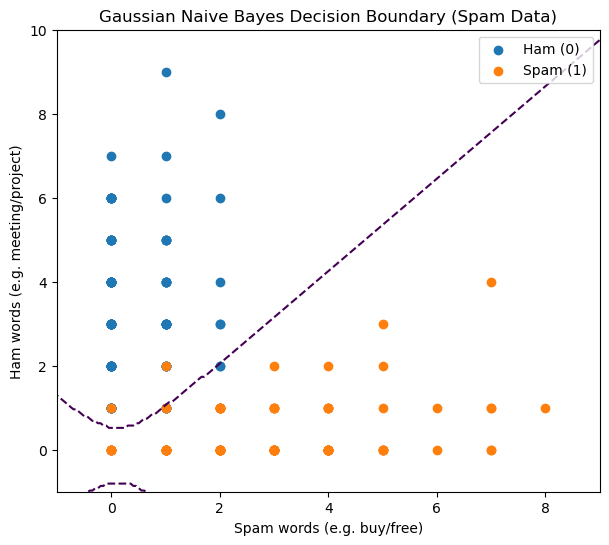

In [8]:
# 1. Create toy spam dataset
np.random.seed(2232)

# Use only 2 features for visualization:
# [spam_word_count, ham_word_count]

# Spam class (1): high spam words, low ham words
spam = np.random.poisson(lam=[3, 0.5], size=(100, 2))

# Ham class (0): low spam words, high ham words
ham = np.random.poisson(lam=[0.5, 3], size=(100, 2))

X = np.vstack([ham, spam])
y = np.array([0]*100 + [1]*100)


# 2. Train Gaussian Naive Bayes
model = GaussianNB()
model.fit(X, y)

print("Accuracy:", model.score(X, y))


# 3. Plot decision boundary
# Create grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# Predict on grid
Z = model.predict(grid)
Z = Z.reshape(xx.shape)


# 4. Plot
plt.figure(figsize=(7,6))

# Decision boundary
plt.contour(xx, yy, Z, levels=[0.5], linestyles="--")

# Data points
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], label="Ham (0)")
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], label="Spam (1)")

plt.xlabel("Spam words (e.g. buy/free)")
plt.ylabel("Ham words (e.g. meeting/project)")
plt.title("Gaussian Naive Bayes Decision Boundary (Spam Data)")
plt.legend()
plt.show()